In [24]:
import pandas as pd 

df = pd.read_csv('sample_data.csv')

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df_lable = df.copy()

df_lable.columns = df_lable.columns.str.strip()

In [25]:
le = LabelEncoder()

df_lable['gender_encoded'] = le.fit_transform(df_lable['Gender'])
df_lable['Passed_encoded'] = le.fit_transform(df_lable['Passed'])
print(df_lable)

      Name   Gender        City Passed  gender_encoded  Passed_encoded
0     Aman     Male       Delhi    Yes               1               1
1    Priya   Female      Mumbai    Yes               0               1
2    Rahul     Male   Bangalore     No               1               0
3   Anjali   Female      Mumbai    Yes               0               1
4     Ravi     Male       Delhi    Yes               2               1
5    Meera   Female     Chennai     No               0               0
6    Arjun     Male   Bangalore    Yes               1               1
7     Neha   Female       Delhi    Yes               0               1
8    Imran     Male     Chennai     No               1               0
9    Sneha   Female      Mumbai    Yes               0               1
10     Raj     Male     Chennai    Yes               2               1
11   Divya   Female       Delhi     No               0               0
12   Kabir     Male      Mumbai    Yes               1               1
13  Si

In [26]:
df_one_hot = pd.get_dummies(df_lable, columns=['City'],  dtype=int)
print(df_one_hot)

      Name   Gender Passed  gender_encoded  Passed_encoded  City_ Bangalore  \
0     Aman     Male    Yes               1               1                0   
1    Priya   Female    Yes               0               1                0   
2    Rahul     Male     No               1               0                1   
3   Anjali   Female    Yes               0               1                0   
4     Ravi     Male    Yes               2               1                0   
5    Meera   Female     No               0               0                0   
6    Arjun     Male    Yes               1               1                1   
7     Neha   Female    Yes               0               1                0   
8    Imran     Male     No               1               0                0   
9    Sneha   Female    Yes               0               1                0   
10     Raj     Male    Yes               2               1                0   
11   Divya   Female     No               0          

In [27]:
ohe = OneHotEncoder(sparse_output=False)
# # sparse=False ka matlab hai ke output ko dense array mai convert kar do
encoded = ohe.fit_transform(df_lable[['City']])
# # raw matrix data
# print(encoded)

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['City']))
# print(encoded_df)

In [28]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

data = {
    "studyHours" : [2, 4, 6, 8, 10, 12, 14, 15, 16, 20],
    "TestScore" : [50, 55, 60, 65, 70, 75, 80, 85, 90, 100]
}

df = pd.DataFrame(data)

StandardScaled = StandardScaler().fit_transform(df)
print("Standerd scaler output")
print(pd.DataFrame(StandardScaled, columns=['studyHours', 'TestScore']))

Standerd scaler output
   studyHours  TestScore
0   -1.598822  -1.513289
1   -1.231277  -1.184313
2   -0.863731  -0.855337
3   -0.496186  -0.526361
4   -0.128641  -0.197386
5    0.238904   0.131590
6    0.606450   0.460566
7    0.790222   0.789542
8    0.973995   1.118518
9    1.709085   1.776470


In [29]:
MinMaxScaled = MinMaxScaler().fit_transform(df)
print("MinMax scaler output")
print(pd.DataFrame(MinMaxScaled, columns=['studyHours', 'TestScore']))

MinMax scaler output
   studyHours  TestScore
0    0.000000        0.0
1    0.111111        0.1
2    0.222222        0.2
3    0.333333        0.3
4    0.444444        0.4
5    0.555556        0.5
6    0.666667        0.6
7    0.722222        0.7
8    0.777778        0.8
9    1.000000        1.0


In [30]:
X = df[['studyHours']]
y = df[['TestScore']]

X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

# xtrain or ytrain se model train hoga or xtest or ytest se check hoga train main 80% data hoga or test main 20% data hoga random state 42 is leay takay rh bar same rwsult aye 

print("\ntraining ky leya ya data use hoga")
print(f'{X_train},\n{y_train}')

print("\ntesting ky leya ya data use hoga")
print(f'{X_test},\n{y_test}')


training ky leya ya data use hoga
   studyHours
5          12
0           2
7          15
2           6
9          20
4          10
3           8
6          14,
   TestScore
5         75
0         50
7         85
2         60
9        100
4         70
3         65
6         80

testing ky leya ya data use hoga
   studyHours
8          16
1           4,
   TestScore
8         90
1         55


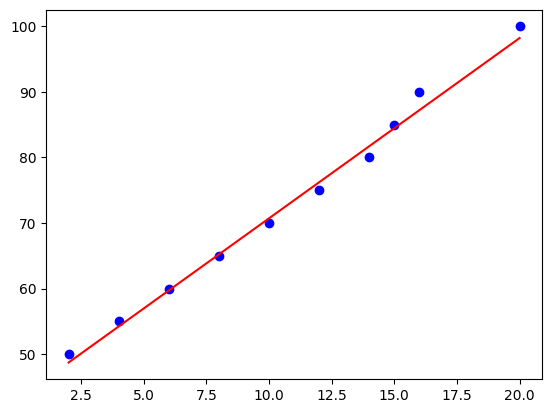

you marks around [87.22378015 54.21200224]
actual marks [90, 55]


In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

model = LinearRegression()

X = [[2], [4], [6], [8], [10], [12], [14], [15], [16], [20]]
y = [50, 55, 60, 65, 70, 75, 80, 85, 90, 100]

X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=42)

model.fit(X_train, y_train)
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.show()


predict_mark =model.predict(X_test)
print(f"you marks around {predict_mark}")
print('actual marks', y_test)


In [1]:
from sklearn.linear_model import LogisticRegression

# tumor size (X)
X = [[2], [4], [6], [8], [10], [12]]
# 0 = safe, 1 = cancer
y = [0, 0, 0, 1, 1, 1]

model = LogisticRegression()

model.fit(X,y)

input_size = float(input("Enter tumor size in cm: "))
result = model.predict([[input_size]])[0]
proba = model.predict_proba([[input_size]])
label = "Cancerous" if result == 1 else "Not Cancerous"
print(f"Tumor size {input_size} cm, prediction: {label}")
print("Probability:")
print("Safe %:", proba[0][0] * 100)
print("Risk %:", proba[0][1] * 100)



Tumor size 11.0 cm, prediction: Cancerous
Probability:
Safe %: 2.121549153565838
Risk %: 97.87845084643416


In [26]:
from sklearn.neighbors import KNeighborsClassifier

x = [
   [8.5, 120],  # Movie 1: Action (High rating, long)
   [7.9, 110],  # Movie 2: Action
   [6.1, 95],   # Movie 3: Comedy (Low rating, short)
   [6.5, 90],   # Movie 4: Comedy
   [8.0, 140],  # Movie 5: Drama (High rating, very long)
   [7.5, 130]   # Movie 6: Drama
]

y = ['Action', 'Action', 'Comedy', 'Comedy', 'Drama', 'Drama']

model = KNeighborsClassifier(n_neighbors=3)
model.fit(x, y)
movie_rating = float(input("Enter movie rating (0-10): "))
movie_length = float(input("Enter movie length in minutes: "))

movie_features = [[movie_rating, movie_length]]
predicted_genre = model.predict(movie_features)[0]
print(f"The predicted genre for the movie is: {predicted_genre}")

The predicted genre for the movie is: Action


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

data = {
    "Income": [
        25000,
        35000,
        60000,
        80000,
        20000,
        55000,
        90000,
        40000,
        75000,
        120000,
    ],
    "Credit_Score": [600, 650, 720, 780, 580, 710, 800, 630, 740, 820],
    "Existing_Loan": [1, 1, 0, 0, 1, 0, 0, 1, 1, 0],
    "Loan_Approved": [
        0,
        0,
        1,
        1,
        0,
        1,
        1,
        0,
        1,
        1,
    ],  # 0 = Reject, 1 = Approve
}

df = pd.DataFrame(data)

X = df[["Income", "Credit_Score", "Existing_Loan"]]
y = df["Loan_Approved"]

model = DecisionTreeClassifier()
model.fit(X, y)

income = float(input("Enter Income (Monthly): "))
credit_score = float(input("Enter Credit Score: "))
existing_loan = int(input("Do you have an existing loan? (0 = No, 1 = Yes): "))

result = model.predict([[income, credit_score, existing_loan]])


if result[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")






Loan Rejected
[[1. 0.]]


c:\Users\Tech Mart\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\Tech Mart\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

X = [
    #fever, cough, loss_of_taste_smell, joint_pain
    #[1   ,     1,                   1,          0],  # Patient example
    [1, 1, 0, 0],  # Patient 1
    [1, 1, 1, 0],  # Patient 2
    [1, 1, 0, 1],  # Patient 3
    [1, 0, 1, 0],  # Patient 4
    [1, 0, 0, 1],  # Patient 5
    [1, 1, 1, 0],  # Patient 6
    [1, 0, 0, 1],  # Patient 7
    [1, 1, 0, 0],  # Patient 8
    [0, 1, 0, 0],  # Patient 9
    [1, 1, 1, 0],  # Patient 10
]

y = ["Flu", "Covid-19", "Chikungunya", "Covid-19", "Chikungunya", "Covid-19", "Chikungunya", "Flu", "Flu", "Covid-19"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train,y_train)

# fever = int(input("Do you have a fever? (1 = Yes, 0 = No): "))
# cough = int(input("Do you have a cough? (1 = Yes, 0 = No): "))
# loss_of_taste_smell = int(input("Do you have loss of taste or smell? (1 = Yes, 0 = No): "))
# joint_pain = int(input("Do you have joint pain? (1 = Yes, 0 = No): "))
# model_input = [[fever, cough, loss_of_taste_smell, joint_pain]]
# model_prediction = model.predict(model_input)[0]

y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# if model_prediction == "Covid-19":
#     print("You may have the Covid-19.")  
# elif model_prediction == "Chikungunya":
#     print("You may have Chikungunya.")
# else:
#     print("You may have the Flu.")





Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

    Covid-19       1.00      1.00      1.00         1
         Flu       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



[ Kya Bukhar (Fever) hai? ]
                             /   \
                       (Na) /     \ (Haan)
                           /       \
               [ Normal Flu ]     [ Kya Taste/Smell chala gaya? ]
                                            /   \
                                      (Na) /     \ (Haan)
                                          /       \
                [ Kya Jodon mein dard hai? ]     [ Covid-19 ]
                             /   \
                       (Na) /     \ (Haan)
                           /       \
               [ Normal Flu ]     [ Chikungunya ]

[ gini/information-gain ya decide karta hain root node kya hoga ]

                          Root Node (tree)
                             /   \
                    branch  /     \  branch
                           /       \
               [ decision node ]     [ decision node ] (sub_tree)
                                            /   \
                                    branch /     \  branch
                                          /       \
 (sub_tree)[ sub_decision_node/internal node ]    [ sub_decision_node/internal node ]
                             /   \
                    branch  /     \ branch
                           /       \
                     [ leaf ]      [ leaf ]  leaf wahi hoga jaha decision ka outcome aye ga


jb model overfit ho jate hain tu hum kuch sub_tree ko hata detay hain tu is process ko hum pruning bolte hain 

Root Node:
root node wo node hoga jis impurity/gini_impurity zeyda hogi or information gain kam hoga like koi asa sawal hain jis base pr hum direct result ni e sakte tu woh root sawal hoga mean root node jis ki impiurity zeyad hain or information gain kam hain jasy jasy sawal pochy gay mean tree bane gay tu information gain zeyad hoga or impurity kam hogi 

Entropy:
Entropy batati hai ke data mein kitni uncertainty (confusion) hai.
Entropy=−∑pi​log2​(pi​)
p matlab os tree main se kitne sawal nikal rahe hain 
Entropy zeyda hogi sawal utna root node kareeb higa ya rooot node he hoga 

Gini Impurity:
Gini = 1−∑pi2​
Gini bhi yahi batata hai ke data kitna mixed hai, lekin formula alag use karta hai.

Socho ek basket mein balls hain.
10 Red, 0 Blue → Pure → Entropy = 0, Gini = 0
5 Red, 🔵 5 Blue → Sab se zyada mixed → Entropy aur Gini dono high honge.

10 0r 0 ya 5 or 5 p ki value hain 10 hain or 10 main se 10 he red mean sb ak he class se hain entropy zero or jb b entropy zero aye tu samaj jao wo leaf node waha information gain zeyda hain or entropy or gini kam hain 

Information Gain = Parent Entropy − Weighted Child Entropy

Parent Entropy = Split se pehle data ki confusion.
Child Entropy = Split ke baad har group ki confusion.
Weighted Child Entropy = Har child group ki entropy ko us group ke size ke hisaab se weight dena.

Weighted" ka matlab kya hai?
Weighted ka matlab hai har child node ko uske records ki tadaad ke mutabiq importance dena.
Agar ek child mein 8 records hain aur doosre mein 2, to 8 wala group zyada weight lega.

Maan lo total 10 students hain.

Split karne ke baad:
Left Child
8 students
Entropy = 0.5

Right Child
2 students
Entropy = 1

Ab Weighted Child Entropy nikalo:
8/10 * 0.5 + 2/10 * 1

Step by step:
Left weight = 8/10 = 0.8
Right weight = 2/10 = 0.2

Ab:
0.8×0.5=0.4
0.2×1=0.2

Dono ko add karo:
0.4+0.2=0.6

Weighted Child Entropy = 0.6

Ab Information Gain
Agar Parent Entropy = 0.9 thi, to:
Information Gain= 0.9−0.6 = 0.3

Yani is split ne 0.3 confusion kam kar di.
Yaad rakhne ka shortcut
Weighted Child Entropy =
(Child 1 ka size ÷ Total size × Child 1 ki Entropy) + (Child 2 ka size ÷ Total size × Child 2 ki Entropy) + ...

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1 0]
 [0 1]]


In [ ]:
from sklearn.metrics import confusion_matrix
# TP, FP, FN, aur TN Confusion Matrix ke 4 basic outcomes hain. Ye batate hain ke model ne prediction sahi ki ya ghalat.

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"True Negatives (TN):  {tn}  (Sahi Naa)")
print(f"False Positives (FP): {fp}  (Galat Haan - False Alarm)")
print(f"False Negatives (FN): {fn}  (Galat Naa - Missed)")
print(f"True Positives (TP):  {tp}  (Sahi Haan)")
print("-" * 32)

# TP Model ne Positive predict kiya aur asal mein bhi Positive tha.
# TN Model ne Negative predict kiya aur asal mein bhi Negative tha.
# FP Model ne Positive predict kiya lekin asal mein Negative tha.
# FN Model ne Negative predict kiya lekin asal mein Positive tha.

True Negatives (TN):  1  (Sahi Naa)
False Positives (FP): 0  (Galat Haan - False Alarm)
False Negatives (FN): 0  (Galat Naa - Missed)
True Positives (TP):  1  (Sahi Haan)
--------------------------------


In [3]:
# feauture selection 
import pandas as pd

df = pd.DataFrame({
    "Study_Hours": [1, 2, 3, 4, 5, 6],
    "Sleep_Hours": [8, 7, 6, 5, 4, 3],
    "Marks": [35, 45, 55, 65, 75, 85]
})

# print(df)
# df.corr() 
# print(df.corr())ya relation bata hain kis col ka kis sath kasa relation hain 1 acha 0 koi khas ni -1 mean ak col sath acha hain
# df.corr()["Marks"].drop("Marks")

corr = df.corr()["Marks"].drop("Marks")
selected = corr[abs(corr) > 0.5]
print(selected)

selected2 = corr[corr > 0.5]
print(selected2)



Study_Hours    1.0
Sleep_Hours   -1.0
Name: Marks, dtype: float64
Study_Hours    1.0
Name: Marks, dtype: float64


In [19]:
#Chi-Square Test (Feature Selection Filter Method)
import pandas as pd
from sklearn.feature_selection import chi2
# Bank Loan dataset
data = {
    "Age_Group": [1, 2, 1, 3, 2, 3, 1, 2, 3, 1],
    # "Job_Type": [0, 1, 0, 1, 1, 1, 0, 1, 1, 0],
    "Education": [1, 2, 1, 2, 2, 3, 1, 2, 3, 1],
    "Credit_Score": [1, 2, 1, 3, 2, 3, 1, 2, 3, 1],
    "City": [0, 1, 2, 1, 0, 2, 1, 0, 2, 1],
    "Income_Level": [1, 2, 1, 3, 2, 3, 1, 2, 3, 1],
    
    # Target
    "Loan_Approved": [0, 1, 0, 1, 1, 1, 0, 1, 1, 0]
}


df = pd.DataFrame(data)

# X = input features
X = df.drop("Loan_Approved", axis=1)

# y = target
y = df["Loan_Approved"]

score, p_value = chi2(X, y)

result = pd.DataFrame({
    "Feature": X.columns,
    "Chi_Square_Score": score,
    "P_Value": p_value
})


print(result)

# score depend karta hain data set pr Categories ki quantity par
# Values ke distribution par

# lakin p-value depend karta hain data set pr Categories ki quality par



        Feature  Chi_Square_Score   P_Value
0     Age_Group          2.842105  0.091824
1     Education          2.370370  0.123658
2  Credit_Score          2.842105  0.091824
3          City          0.000000  1.000000
4  Income_Level          2.842105  0.091824


In [20]:
# ANOVA (Analysis of Variance) — Feature Selection Filter Method
import pandas as pd
from sklearn.feature_selection import f_classif

data = {
    "Experience": [1,2,3,5,6,8,10,12,15],
    "Age": [22,25,28,30,32,35,40,45,50],
    "Education": [1,1,2,2,2,3,3,3,3],
    
    "Job_Level": [0,0,0,1,1,1,2,2,2]
}
df = pd.DataFrame(data)

X = df.drop("Job_Level", axis=1)
# Target
y = df["Job_Level"]
# ANOVA
F_score, p_value = f_classif(X, y)

# Result table
result = pd.DataFrame({
    "Feature": X.columns,
    "F_Score": F_score,
    "P_Value": p_value
})

print(result)

      Feature    F_Score   P_Value
0  Experience  25.068966  0.001221
1         Age  22.842975  0.001564
2   Education   9.500000  0.013824


In [ ]:
# Mutual Information (MI) 
import pandas as pd
from sklearn.feature_selection import mutual_info_classif

data = {
    "Age": [25,30,35,40,45,50,55,60],
    "Monthly_Charges": [100,200,300,400,500,600,700,800],
    "Tenure": [1,2,3,4,5,6,7,8],
    "Contract_Type": [0,1,0,1,0,1,0,1],
    "Churn": [1,0,1,0,1,0,0,0]
}
df = pd.DataFrame(data)
# Features
X = df.drop("Churn", axis=1)
# Target
y = df["Churn"]
# Mutual Information
mi_score = mutual_info_classif(X, y)

# Result
result = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_score
})


print(result)
# Churn ka matlab hota hai customer ka company/service chhor dena (customer leaving or cancellation).

           Feature  MI_Score
0              Age  0.000000
1  Monthly_Charges  0.011607
2           Tenure  0.011607
3    Contract_Type  1.380357


In [25]:
# Wrapper Method — Feature Selection with Recursive Feature Elimination (RFE)
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

data = {
    "Age": [25,30,35,40,45,50],
    "Income": [20000,30000,40000,50000,60000,70000],
    "Tenure": [1,2,3,4,5,6],
    "Charges": [100,200,300,400,500,600],
    
    "Churn": [1,0,1,0,0,1]
}

df = pd.DataFrame(data)
# Features
X = df.drop("Churn", axis=1)
# Target
y = df["Churn"]

# Model
model = RandomForestClassifier()

# RFE
rfe = RFE(
    estimator=model,
    n_features_to_select=2
)

rfe.fit(X, y)

result = pd.DataFrame({
    "Feature": X.columns,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_
})


print(result)

   Feature  Selected  Rank
0      Age     False     3
1   Income      True     1
2   Tenure     False     2
3  Charges      True     1


In [29]:
# embbedded method
# lasso regression (L1 regularization) — Feature Selection with Embedded Method
import pandas as pd
from sklearn.linear_model import Lasso

data = {
    "Area": [1000,1500,2000,2500,3000],
    "Rooms": [2,3,4,4,5],
    "Age": [20,15,10,5,2],
    "Color": [1,2,1,2,1],

    "Price": [200000,300000,450000,550000,700000]
}

df = pd.DataFrame(data)

# Features
X = df.drop("Price", axis=1)

# Target
y = df["Price"]

# Lasso model
model = Lasso(alpha=100)
# Training
model.fit(X,y)
# Coefficients
result = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(result)

  Feature   Coefficient
0    Area    250.734125
1   Rooms      0.000000
2     Age     78.615310
3   Color -24530.923126


In [ ]:
from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
import pandas as pd

# Sample Data
# X = [[1,2], [2,3], [3,4], [4,5], [5,6], [6,7], [7,8], [8,9], [9,10], [10,11]]
# y = [0,0,0,1,1,1,0,0,1,1]

data = pd.read_csv("Salary Data.csv")

data = data.dropna()

education_map = {
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3
}
data["Education Level"] = data["Education Level"].map(education_map)


X = data[['Years of Experience', 'Education Level']]
y = data["Salary"]

# print("Features (X):")
# print(X.head())

# Step 1: Train + Validation aur Test mein split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 2: Train aur Validation mein split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

# Step 3: Model banaya
model = LinearRegression()

# Step 4: Training
# model.fit(X_train, y_train)

# Step 5: Validation Accuracy
val_accuracy = model.score(X_val, y_val)
print("Validation Accuracy:", val_accuracy)

# Step 6: Final Test Accuracy
test_accuracy = model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.8806688247295537
Test Accuracy: 0.9058927654348617


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print(scores)
print("Average R2:", scores.mean())

[0.79058029 0.70386867 0.93331143 0.91330015 0.92608896]
Average R2: 0.8534298983806566


In [22]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression


X = np.array([[1],[2],[3],[4],[5]])

y = np.array([1,4,9,16,25])


poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)


model = LinearRegression()

model.fit(X_poly,y)


prediction = model.predict(
    poly.transform([[6]])
)

print(prediction)

[36.]


In [1]:
# Ordinal Encoding
# Ordinal Encoding mein har category ko ek integer (0,1,2,3...) assign kiya jata hai.
# Ye tab use hota hai jab categories ka natural order ho.
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

df = pd.DataFrame({
    'Education': ['Bachelor', 'Master', 'PhD', 'High School', 'Master']
})

encoder = OrdinalEncoder(categories=[
    ['High School', 'Bachelor', 'Master', 'PhD']
])

df['Education_Encoded'] = encoder.fit_transform(df[['Education']])

print(df)

     Education  Education_Encoded
0     Bachelor                1.0
1       Master                2.0
2          PhD                3.0
3  High School                0.0
4       Master                2.0


In [1]:
# Binary Encoding
# Binary Encoding mein pehle categories ko numbers diye jaate hain, phir un numbers ko binary form mein convert kiya jata hai.

# Ye high-cardinality categorical features ke liye useful hota hai. mean jb data zeyada ho aur # categories zeyada ho to ye kam space leta hai.
# pip install category_encoders
import pandas as pd
from category_encoders import BinaryEncoder

df = pd.DataFrame({
    'City': ['Karachi', 'Lahore', 'Islamabad', 'Peshawar']
})

encoder = BinaryEncoder(cols=['City'])

encoded = encoder.fit_transform(df)

print(encoded)

   City_0  City_1  City_2
0       0       0       1
1       0       1       0
2       0       1       1
3       1       0       0


In [2]:
# Frequency Encoding
# Har category ko uski dataset mein aane ki frequency (count) se replace kiya jata hai.

import pandas as pd

df = pd.DataFrame({
    'Fruit': [
        'Apple',
        'Apple',
        'Banana',
        'Orange',
        'Apple',
        'Banana'
    ]
})

freq = df['Fruit'].value_counts()

df['Frequency'] = df['Fruit'].map(freq)
print(df)

    Fruit  Frequency
0   Apple          3
1   Apple          3
2  Banana          2
3  Orange          1
4   Apple          3
5  Banana          2


In [ ]:
import sys
print(sys.executable)
import sys

# sys Python ka built-in module hai jo Python interpreter ke baare mein information deta hai.
# Jaise:
# Python ka version
# Current environment
# Installed paths
# Python executable ka location


c:\Users\Tech Mart\AppData\Local\Python\pythoncore-3.14-64\python.exe
